In [1]:
import sys
sys.path.append('../')
import UTILS.utils as utils

from PIL import Image

import torch
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import open_clip
import cv2
from sentence_transformers import util

import pandas as pd


# CLIP

In [2]:
images = utils.get_files_in_directory("../../Data/STEREO_VIEWS/LEFT_IMAGE/")
images = images[1:]

In [3]:
# image processing model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-16-plus-240', pretrained="laion400m_e32")
model.to(device)
def imageEncoder(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img1 = Image.fromarray(img).convert('RGB')
    img1 = preprocess(img1).unsqueeze(0).to(device)
    img1 = model.encode_image(img1)
    return img1
def generateScore(image1, image2):
    test_img = cv2.imread(image1, cv2.IMREAD_UNCHANGED)
    data_img = cv2.imread(image2, cv2.IMREAD_UNCHANGED)
    img1 = imageEncoder(test_img)
    img2 = imageEncoder(data_img)
    cos_scores = util.pytorch_cos_sim(img1, img2)
    score = round(float(cos_scores[0][0])*100, 2)
    return score
print(f"similarity Score: ", round(generateScore(images[20], images[21]), 2))

similarity Score:  62.16


In [ ]:
from tqdm import tqdm

def get_similarity_matrix():
    matrix = []
    for ref in tqdm(range(0, 100)):
        similarity = []
        for i in range(0, 100):
            similarity += [generateScore(images[ref], images[i])]
        matrix.append(similarity)
    pd.DataFrame(matrix).to_csv("similarity_matrix.csv")
    return matrix

#matrix = get_similarity_matrix()

In [3]:
matrix = pd.read_csv("../../Data/STEREO_VIEWS/IMAGE_SIMILARITY.csv")

# CLUSTERING

In [4]:
def create_clusters(labels):
    final_dict = {}
    for i, label in enumerate(labels):
        if label in final_dict.keys():
            final_dict[label] += [i]
        else:
            final_dict[label] = [i]
    return final_dict

In [5]:
similarity_matrix = matrix.values.tolist()
similarity_matrix = np.array([x[1:] for x in similarity_matrix])
distance_matrix = 1 - (similarity_matrix / 100.0)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=20, linkage='complete', metric="precomputed").fit(distance_matrix)
label_dict = create_clusters(model.labels_)

In [12]:
distr = [len(x) for x in label_dict.values()]
data = pd.DataFrame(zip(label_dict.keys(), distr), columns=["Cats", "Num"])

In [7]:
def display_images(image_indexes):
    for idx in image_indexes:
        img = cv2.imread(images[idx])
        plt.figure()
        plt.imshow(img)
    plt.show()

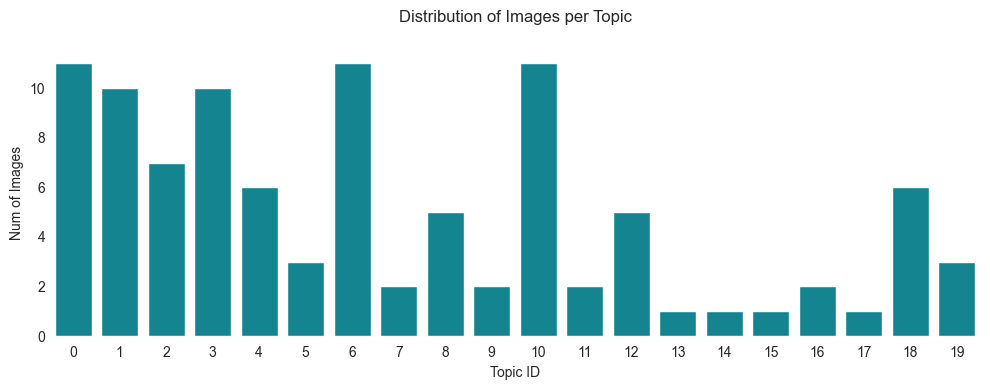

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Cats', y='Num', data=data,
                 color='#0094a6') 

plt.xlabel('Topic ID') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Images')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Distribution of Images per Topic', pad=20)

plt.tight_layout()
plt.show()

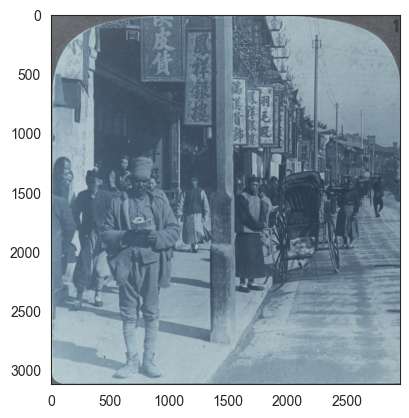

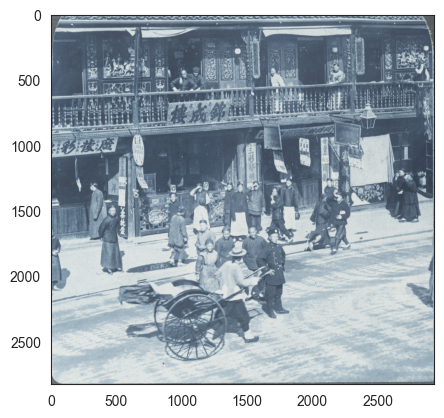

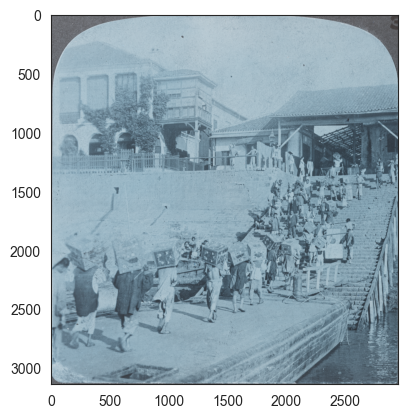

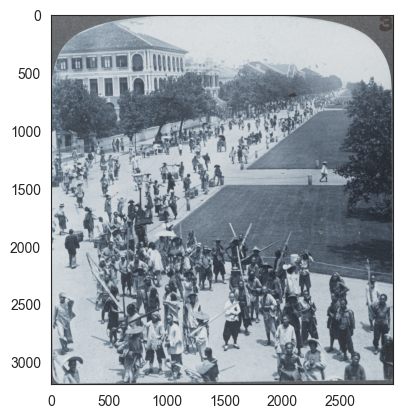

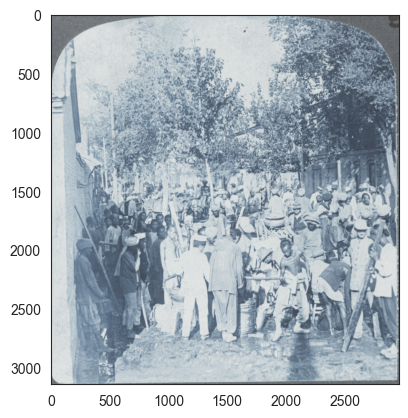

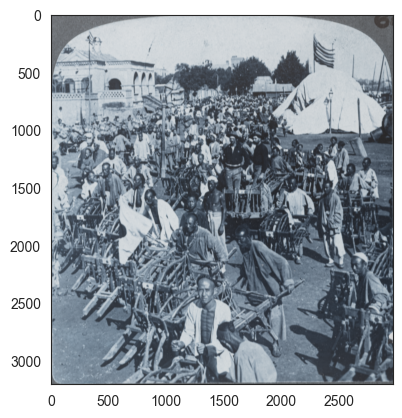

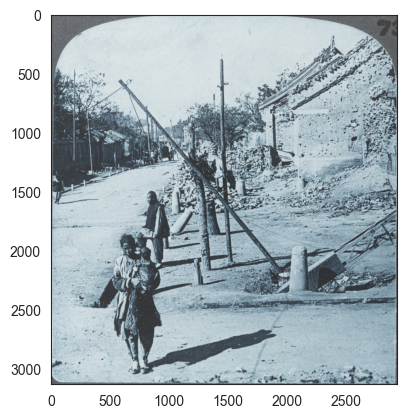

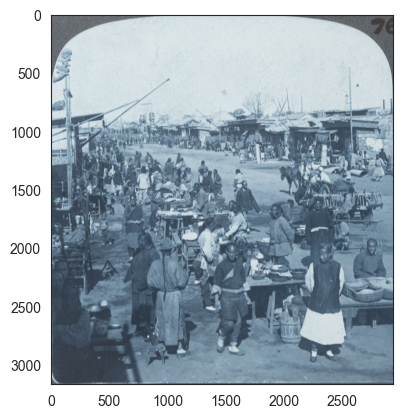

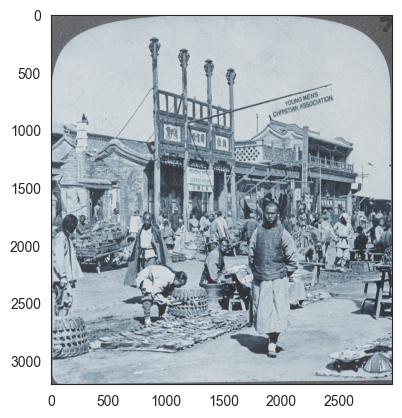

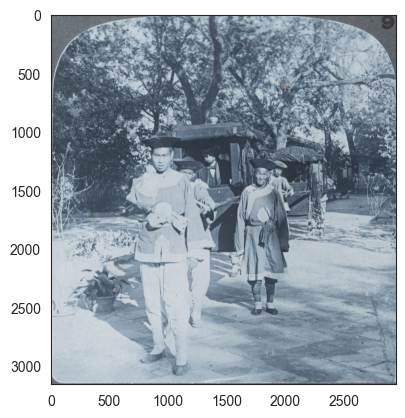

In [14]:
display_images(label_dict[1])